In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import kagglehub

susendran45_graduate_admission_dataset_path = kagglehub.dataset_download(
    'susendran45/graduate-admission-dataset'
)

print('Data source import complete.')

100%|██████████| 2.23k/2.23k [00:00<00:00, 4.99MB/s]

Extracting files...
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Machine Learning Lab – Experiment 2
## Logistic Regression – Graduate Admission Prediction

### Aim
To build a Logistic Regression model to predict whether a student will be admitted to graduate school using GRE score, GPA, and University Prestige.

In [4]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# ============================================
# 2. FIND THE DATASET
# ============================================

print("Dataset Path:")
print(susendran45_graduate_admission_dataset_path)

print("\nFiles in Dataset:")

for root, dirs, files in os.walk(
    susendran45_graduate_admission_dataset_path
):
    for file in files:
        print(os.path.join(root, file))

Dataset Path:
/root/.cache/kagglehub/datasets/susendran45/graduate-admission-dataset/versions/1

Files in Dataset:
/root/.cache/kagglehub/datasets/susendran45/graduate-admission-dataset/versions/1/binary.dta


In [6]:
# ============================================
# 3. LOAD DATASET
# ============================================

file_path = os.path.join(
    susendran45_graduate_admission_dataset_path,
    "binary.dta"
)

df = pd.read_stata(file_path)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (400, 4)


,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [8]:
# ============================================
# 4. DATASET INFORMATION
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(400, 4)

Column Names:
['admit', 'gre', 'gpa', 'rank']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    float32
 1   gre     400 non-null    float32
 2   gpa     400 non-null    float32
 3   rank    400 non-null    float32
dtypes: float32(4)
memory usage: 6.4 KB

Data Types:
admit    float32
gre      float32
gpa      float32
rank     float32
dtype: object


In [9]:
# ============================================
# 5. STATISTICAL SUMMARY
# ============================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
admit,400.0,0.317500,0.466087,0.00,0.00,0.000,1.00,1.0
gre,400.0,587.700012,115.516663,220.00,520.00,580.000,660.00,800.0
gpa,400.0,3.389900,0.380567,2.26,3.13,3.395,3.67,4.0
rank,400.0,2.485000,0.944462,1.00,2.00,2.000,3.00,4.0


In [10]:
# ============================================
# 6. MISSING VALUE ANALYSIS
# ============================================

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

display(missing_summary)

,Missing Values,Percentage
admit,0,0.0
gre,0,0.0
gpa,0,0.0
rank,0,0.0


In [11]:
# ============================================
# 7. UNIQUE VALUES
# ============================================

for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())


admit:
[0. 1.]

gre:
[380. 660. 800. 640. 520. 760. 560. 400. 540. 700. 440. 480. 780. 360.
 500. 600. 680. 620. 580. 460. 740. 300. 720. 340. 420. 220.]

gpa:
[3.61 3.67 4.   3.19 2.93 3.   2.98 3.08 3.39 3.92 3.22 3.44 3.87 2.56
 3.75 3.81 3.17 3.63 2.82 3.35 3.66 3.74 3.29 3.78 3.4  3.14 3.05 3.25
 2.9  3.13 2.68 2.42 3.32 3.15 3.31 2.94 3.45 3.46 2.97 2.48 3.86 3.37
 3.27 3.34 3.65 3.18 3.85 3.59 3.62 3.3  3.69 3.73 2.92 3.36 3.12 3.07
 2.71 2.91 3.6  3.48 3.28 3.83 3.64 3.9  3.33 3.52 3.57 2.88 3.94 3.95
 3.56 3.41 3.84 3.99 3.72 3.7  2.67 2.85 3.88 3.38 3.54 2.79 2.95 3.58
 3.93 3.43 2.86 2.52 3.49 3.82 3.5  2.73 3.24 3.77 3.51 2.81 3.53 2.62
 3.23 3.01 3.76 3.47 3.2  3.89 3.8  3.16 3.02 2.87 3.42 2.76 2.96 3.04
 3.91 3.21 3.55 3.11 3.1  2.26 2.78 3.97 2.55 3.98 2.83 2.84 3.71 2.69
 2.7  3.09 2.65 3.06 3.03 2.63]

rank:
[3. 1. 4. 2.]


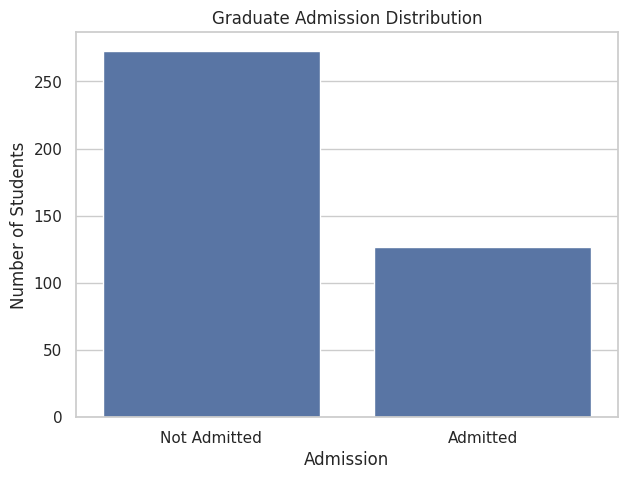

In [12]:
# ============================================
# 8. ADMISSION DISTRIBUTION
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="admit"
)

plt.title("Graduate Admission Distribution")
plt.xlabel("Admission")
plt.ylabel("Number of Students")

plt.xticks(
    ticks=[0, 1],
    labels=["Not Admitted", "Admitted"]
)

plt.show()

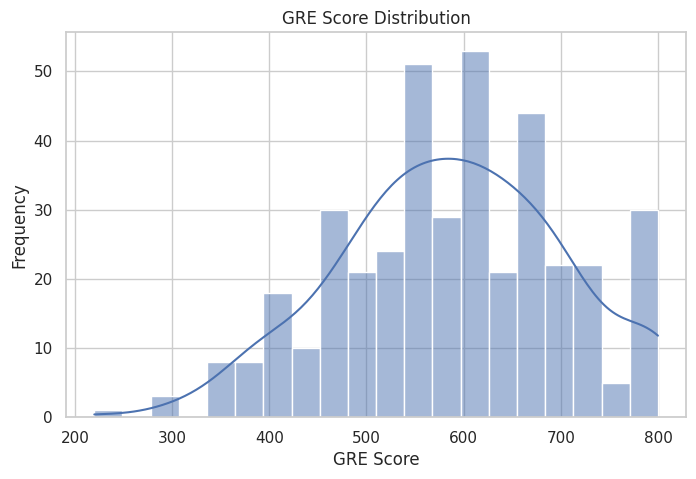

In [13]:
# ============================================
# 9. GRE SCORE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="gre",
    bins=20,
    kde=True
)

plt.title("GRE Score Distribution")
plt.xlabel("GRE Score")
plt.ylabel("Frequency")

plt.show()

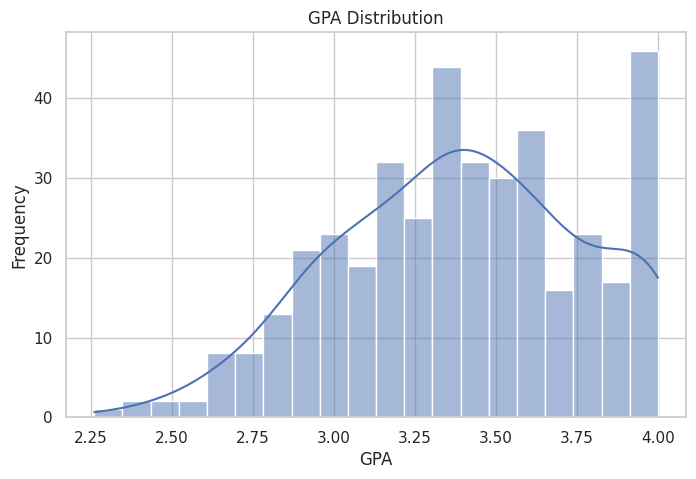

In [14]:
# ============================================
# 10. GPA DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="gpa",
    bins=20,
    kde=True
)

plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.show()

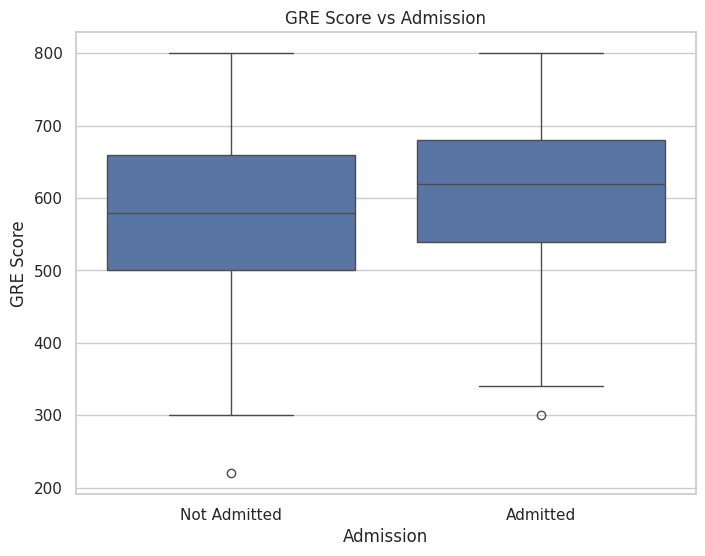

In [15]:
# ============================================
# 11. GRE SCORE VS ADMISSION
# ============================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="admit",
    y="gre"
)

plt.title("GRE Score vs Admission")
plt.xlabel("Admission")
plt.ylabel("GRE Score")

plt.xticks(
    ticks=[0, 1],
    labels=["Not Admitted", "Admitted"]
)

plt.show()

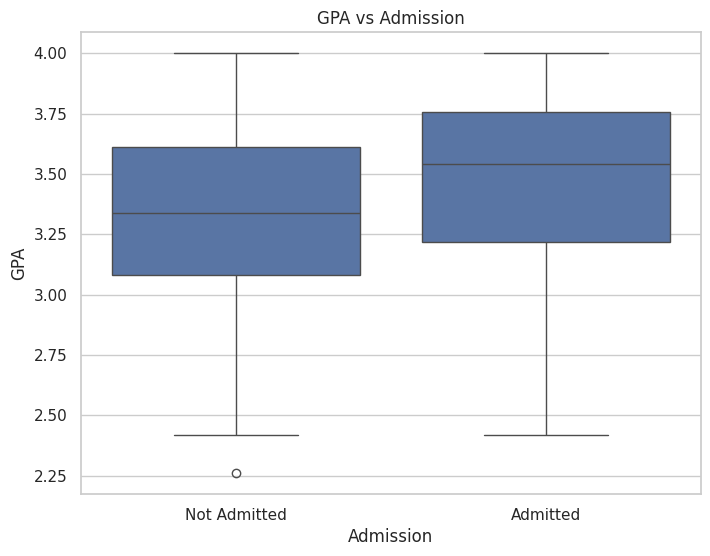

In [16]:
# ============================================
# 12. GPA VS ADMISSION
# ============================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="admit",
    y="gpa"
)

plt.title("GPA vs Admission")
plt.xlabel("Admission")
plt.ylabel("GPA")

plt.xticks(
    ticks=[0, 1],
    labels=["Not Admitted", "Admitted"]
)

plt.show()

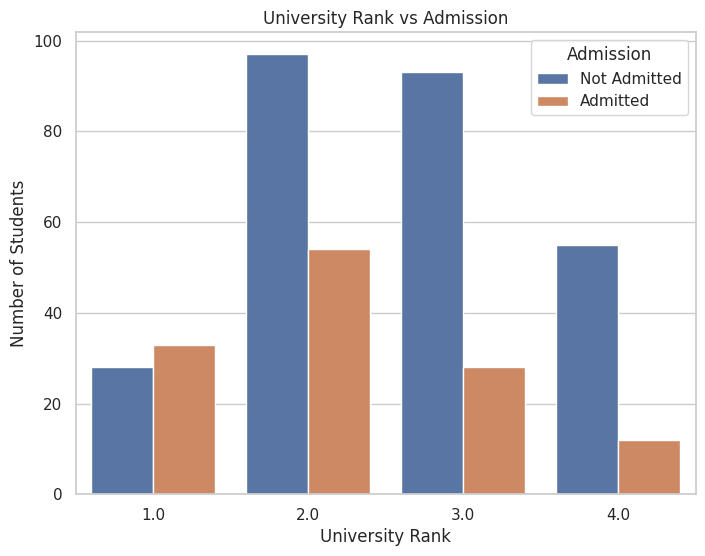

In [17]:
# ============================================
# 13. UNIVERSITY RANK VS ADMISSION
# ============================================

plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="rank",
    hue="admit"
)

plt.title("University Rank vs Admission")
plt.xlabel("University Rank")
plt.ylabel("Number of Students")

plt.legend(
    title="Admission",
    labels=["Not Admitted", "Admitted"]
)

plt.show()

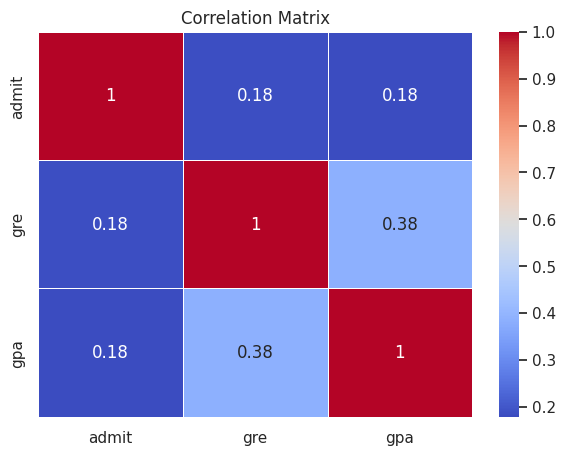

In [18]:
# ============================================
# 14. CORRELATION MATRIX
# ============================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    df[["admit", "gre", "gpa"]].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

In [19]:
# ============================================
# 15. HANDLE MISSING VALUES
# ============================================

print("Missing values before cleaning:")

print(
    df[["admit", "gre", "gpa", "rank"]]
    .isnull()
    .sum()
)

df = df.dropna().copy()

# Convert target and rank to integer
df["admit"] = df["admit"].astype(int)
df["rank"] = df["rank"].astype(int)

print("\nDataset Shape After Cleaning:")
print(df.shape)

Missing values before cleaning:
admit    0
gre      0
gpa      0
rank     0
dtype: int64

Dataset Shape After Cleaning:
(400, 4)


In [20]:
# ============================================
# 16. ONE-HOT ENCODING UNIVERSITY RANK
# ============================================

df = pd.get_dummies(
    df,
    columns=["rank"],
    drop_first=True,
    dtype=int
)

print("Dataset After One-Hot Encoding:")

display(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset After One-Hot Encoding:


,admit,gre,gpa,rank_2,rank_3,rank_4
0,0,380.0,3.61,0,1,0
1,1,660.0,3.67,0,1,0
2,1,800.0,4.00,0,0,0
3,1,640.0,3.19,0,0,1
4,0,520.0,2.93,0,0,1



Columns:
['admit', 'gre', 'gpa', 'rank_2', 'rank_3', 'rank_4']


In [21]:
# ============================================
# 17. DEFINE FEATURES AND TARGET
# ============================================

X = df.drop("admit", axis=1)
y = df["admit"]

print("Features:")

display(X.head())

print("\nTarget:")

display(y.head())

Features:


,gre,gpa,rank_2,rank_3,rank_4
0,380.0,3.61,0,1,0
1,660.0,3.67,0,1,0
2,800.0,4.00,0,0,0
3,640.0,3.19,0,0,1
4,520.0,2.93,0,0,1



Target:


,admit
0,0
1,1
2,1
3,1
4,0


In [22]:
# ============================================
# 18. TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 320
Testing samples : 80


In [23]:
# ============================================
# 19. FEATURE SCALING
# ============================================

X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()

numerical_features = ["gre", "gpa"]

X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [24]:
# ============================================
# 20. TRAIN LOGISTIC REGRESSION MODEL
# ============================================

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [25]:
# ============================================
# 21. MAKE PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Admission": y_test.values,
    "Predicted Admission": y_pred
})

display(results.head(10))

,Actual Admission,Predicted Admission
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0
5,0,0
6,1,0
7,1,0
8,0,0
9,1,0


In [26]:
# ============================================
# 22. PREDICTION PROBABILITIES
# ============================================

probabilities = model.predict_proba(X_test)

probability_results = pd.DataFrame({
    "Actual Admission": y_test.values,
    "Probability of Not Admitted": probabilities[:, 0],
    "Probability of Admitted": probabilities[:, 1],
    "Predicted Admission": y_pred
})

display(probability_results.head(10))

,Actual Admission,Probability of Not Admitted,Probability of Admitted,Predicted Admission
0,0,0.804537,0.195463,0
1,0,0.681314,0.318686,0
2,0,0.722703,0.277297,0
3,0,0.829558,0.170442,0
4,1,0.718689,0.281311,0
5,0,0.599892,0.400108,0
6,1,0.678561,0.321439,0
7,1,0.672241,0.327759,0
8,0,0.864230,0.135770,0
9,1,0.720226,0.279774,0


Confusion Matrix:
[[54  1]
 [20  5]]


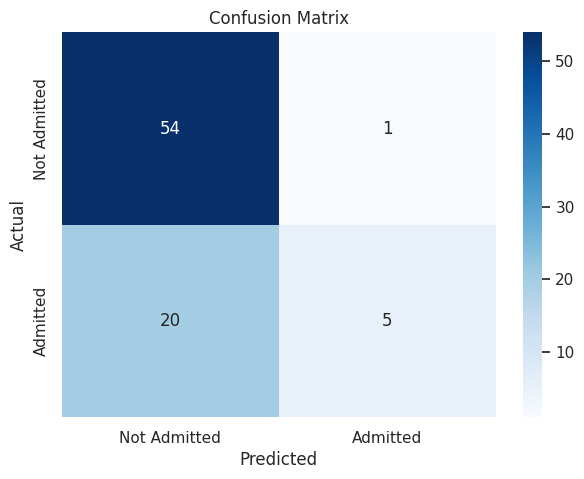

In [27]:
# ============================================
# 23. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Admitted", "Admitted"],
    yticklabels=["Not Admitted", "Admitted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [28]:
# ============================================
# 24. MODEL EVALUATION
# ============================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("=" * 45)
print("   LOGISTIC REGRESSION MODEL RESULTS")
print("=" * 45)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("=" * 45)

   LOGISTIC REGRESSION MODEL RESULTS
Accuracy  : 0.7375
Precision : 0.8333
Recall    : 0.2000
F1 Score  : 0.3226


In [29]:
# ============================================
# 25. CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Admitted",
            "Admitted"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

Not Admitted       0.73      0.98      0.84        55
    Admitted       0.83      0.20      0.32        25

    accuracy                           0.74        80
   macro avg       0.78      0.59      0.58        80
weighted avg       0.76      0.74      0.68        80



In [30]:
# ============================================
# 26. ROC-AUC SCORE
# ============================================

y_prob = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.6913


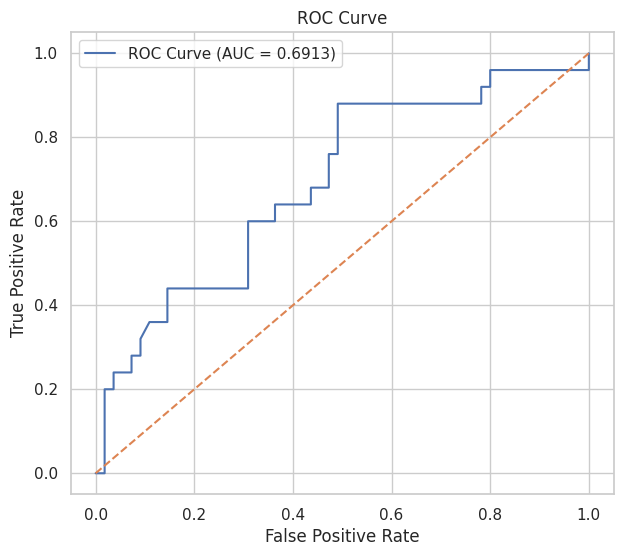

In [31]:
# ============================================
# 27. ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [32]:
# ============================================
# 28. MODEL COEFFICIENTS
# ============================================

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficients)

print("Intercept:", model.intercept_[0])

,Feature,Coefficient
1,gpa,0.346742
0,gre,0.257605
2,rank_2,-0.355980
4,rank_4,-0.880653
3,rank_3,-0.996055


Intercept: -0.2507890251344658


In [33]:
# ============================================
# 29. ACTUAL VS PREDICTED
# ============================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability of Admission": y_prob
})

comparison = comparison.reset_index(drop=True)

display(comparison.head(20))

,Actual,Predicted,Probability of Admission
0,0,0,0.195463
1,0,0,0.318686
2,0,0,0.277297
3,0,0,0.170442
4,1,0,0.281311
5,0,0,0.400108
6,1,0,0.321439
7,1,0,0.327759
8,0,0,0.135770
9,1,0,0.279774


In [34]:
# ============================================
# 30. FINAL MODEL SUMMARY
# ============================================

print("MODEL: Logistic Regression")
print("PROBLEM TYPE: Binary Classification")

print("\nFeatures Used:")
print(list(X.columns))

print("\nTarget Variable:")
print("admit")

print("\nEvaluation Results:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc_score:.4f}")

MODEL: Logistic Regression
PROBLEM TYPE: Binary Classification

Features Used:
['gre', 'gpa', 'rank_2', 'rank_3', 'rank_4']

Target Variable:
admit

Evaluation Results:
Accuracy  : 0.7375
Precision : 0.8333
Recall    : 0.2000
F1 Score  : 0.3226
ROC-AUC   : 0.6913
